In [15]:
# Cell 1: imports and locate files
import os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Working dir:", pathlib.Path.cwd())

# Paths (adjust if your project path differs)
bike_merged = "../data/processed/citi_bike_with_weather_2022.csv"


Working dir: /Users/karen/Desktop/CF/citi-bike-nyc-2022-dashboard/notebooks


In [33]:

df = pd.read_csv(bike_merged, low_memory=False, parse_dates=['started_at', 'ended_at', 'date'])   # low_memory avoids dtype warnings
print("Loaded df shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Loaded df shape: (895485, 15)
Columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'date', 'avgTemp']


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp
0,3255D3E3F33CDC45,classic_bike,2022-03-18 15:38:17,2022-03-18 15:45:34,Mama Johnson Field - 4 St & Jackson St,HB404,South Waterfront Walkway - Sinatra Dr & 1 St,HB103,40.743140,-74.040041,40.736982,-74.027781,casual,2022-03-18,NaN
1,17FA5604A37338F9,electric_bike,2022-03-04 16:44:48,2022-03-04 16:50:45,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-04,NaN
2,7DEC9ADDB8D6BBE1,electric_bike,2022-03-13 17:44:32,2022-03-13 17:54:44,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-13,NaN


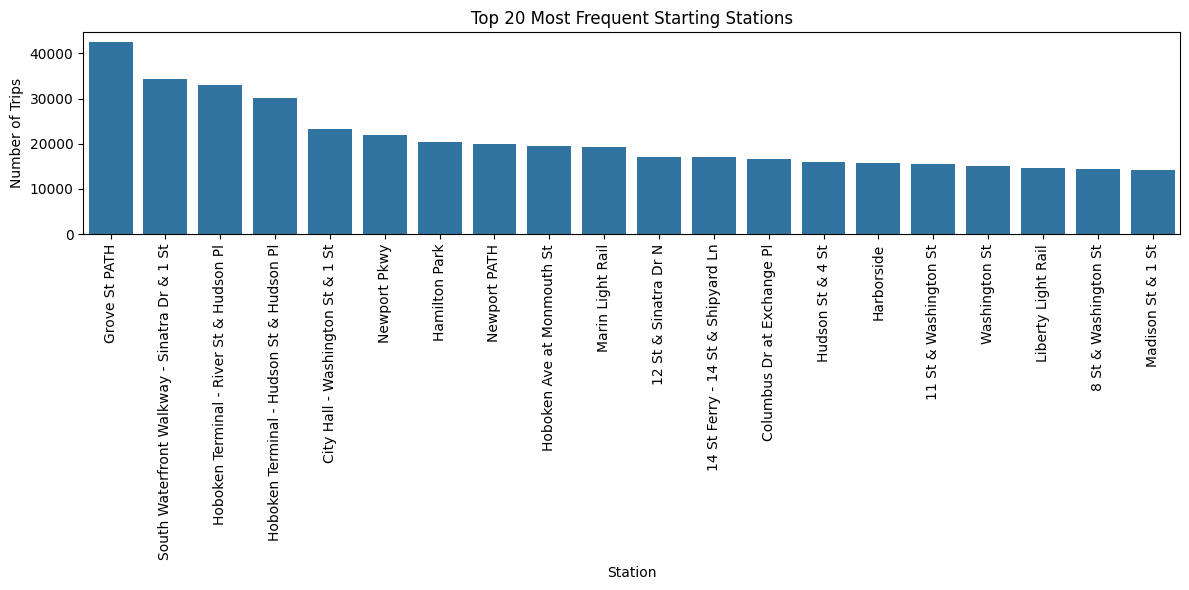

In [17]:
# Get top 20 starting stations
top20 = df['start_station_name'].value_counts().head(20).reset_index()
top20.columns = ['station', 'count']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x='station', y='count')
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Starting Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

/var/folders/lj/zzjljjk13qb24np6ljc9x64w0000gn/T/ipykernel_30236/289508917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


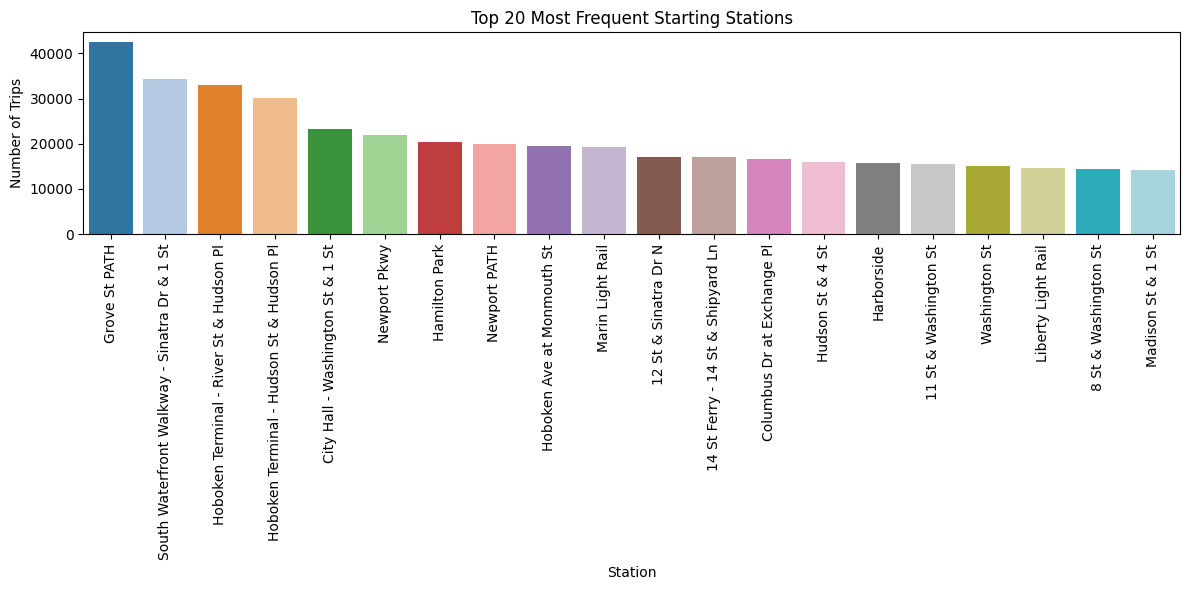

In [18]:
# Temporaray palette for this plot

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top20,
    x='station',
    y='count',
    palette='tab20'   
)

plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Starting Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

In [23]:
# Aggregate data to daily level
daily_df = df.groupby('date').agg(
    rides=('ride_id', 'count'),
    avg_temp=('avgTemp', 'mean')
).reset_index()

daily_df.head()

,date,rides,avg_temp
0,2022-01-01,592,11.6
1,2022-01-02,1248,11.4
2,2022-01-03,832,1.4
3,2022-01-04,934,-2.7
4,2022-01-05,914,3.2


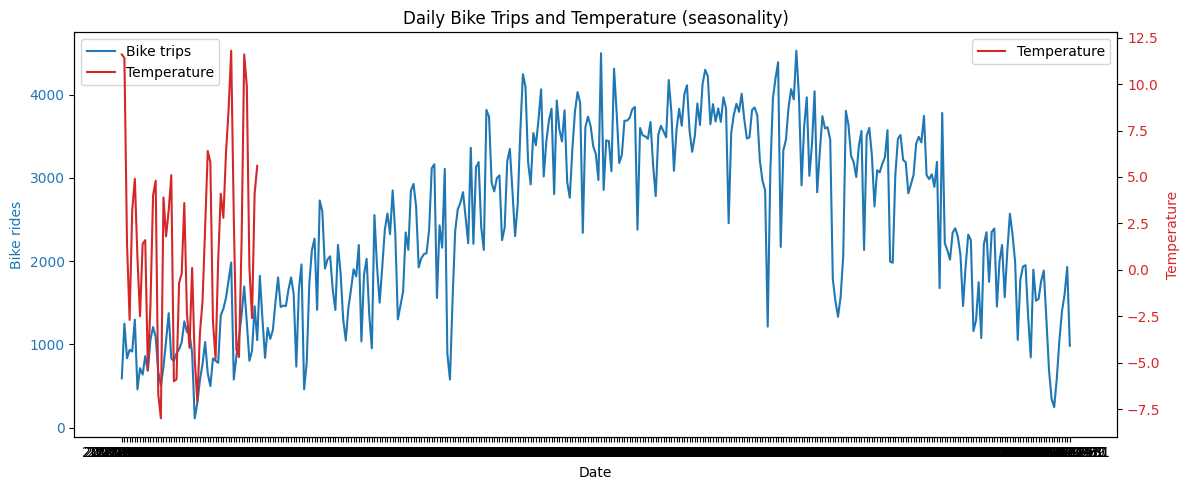

In [27]:
fig, ax1 = plt.subplots(figsize=(12,5))

sns.lineplot(data=daily_df, x='date', y='rides', ax=ax1, color='tab:blue', label='Bike trips')
ax1.set_xlabel('Date')
ax1.set_ylabel('Bike rides', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(data=daily_df, x='date', y='avg_temp', ax=ax2, color='tab:red', label='Temperature')
ax2.set_ylabel('Temperature', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Daily Bike Trips and Temperature (seasonality)")
fig.tight_layout()

# Combined legend (optional)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [34]:
df['ride_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp,ride_duration
0,3255D3E3F33CDC45,classic_bike,2022-03-18 15:38:17,2022-03-18 15:45:34,Mama Johnson Field - 4 St & Jackson St,HB404,South Waterfront Walkway - Sinatra Dr & 1 St,HB103,40.743140,-74.040041,40.736982,-74.027781,casual,2022-03-18,NaN,7.283333
1,17FA5604A37338F9,electric_bike,2022-03-04 16:44:48,2022-03-04 16:50:45,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-04,NaN,5.950000
2,7DEC9ADDB8D6BBE1,electric_bike,2022-03-13 17:44:32,2022-03-13 17:54:44,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-13,NaN,10.200000
3,9D69F74EEF231A2E,classic_bike,2022-03-13 15:33:47,2022-03-13 15:41:22,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-13,NaN,7.583333
4,C84AE4A9D78A6347,classic_bike,2022-03-11 12:21:18,2022-03-11 12:33:24,Baldwin at Montgomery,JC020,Grove St PATH,JC005,40.723659,-74.064194,40.719586,-74.043117,member,2022-03-11,NaN,12.100000


/var/folders/lj/zzjljjk13qb24np6ljc9x64w0000gn/T/ipykernel_30236/279236322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


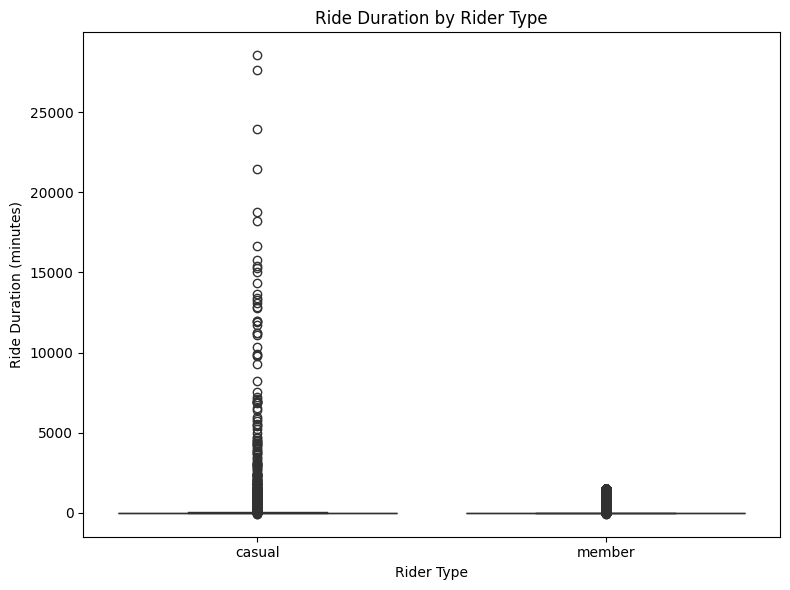

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='member_casual',
    y='ride_duration',
    palette='crest'   # koristi globalnu temu, pa možeš i izostaviti
)
plt.title("Ride Duration by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Ride Duration (minutes)")
plt.tight_layout()
plt.show()

### Box plot analysis (example template)
1. The median trip duration for **Subscribers** is __ minutes, and for **Casuals** is __ minutes.
2. Subscribers show a narrower IQR, indicating more consistent trip durations; Casuals show a wider IQR and more extreme outliers, indicating variable usage (likely leisure trips).
3. Outliers (long trips) are more common among Casuals, possibly reflecting rentals for long leisure trips or data anomalies.
4. Overall, Subscribers appear to be utilitarian (shorter, consistent trips) while Casuals show more variability.


In [36]:
# Day of week column
df['day_of_week'] = df['date'].dt.day_name()

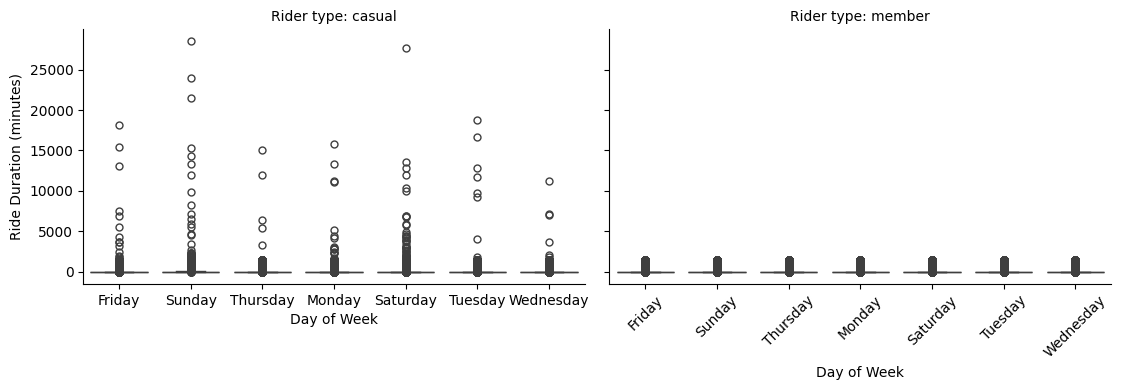

In [38]:
g = sns.catplot(
    data=df,
    x='day_of_week',
    y='ride_duration',
    col='member_casual',
    kind='box',
    height=4,
    aspect=1.4
)

g.set_axis_labels("Day of Week", "Ride Duration (minutes)")
g.set_titles("Rider type: {col_name}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# TODO some interpretation of the plots